In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import IPython.display as ipd
import librosa
import librosa.display
from glob import glob
import seaborn as sns
from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

PATHS = [
    "audios/splitted_audio",
    "audios/rec",
    "audios/filtered_audio",
    "audios/filtered_audio/fir",
    "audios/filtered_audio/bandstop",
    "audios/filtered_audio/bandpass",
    "audios/filtered_audio/highpass",
    "audios/filtered_audio/lowpass",
]

REC_PATH = PATHS[1]

In [12]:
audio_files = glob(f'{REC_PATH}*.wav')
audio_files[2]

'rec\\rec3.wav'

In [3]:
ipd.Audio(audio_files[2])

In [4]:
# sr none to get original sample rate of audio file
y, sr = librosa.load(audio_files[0], sr=None)

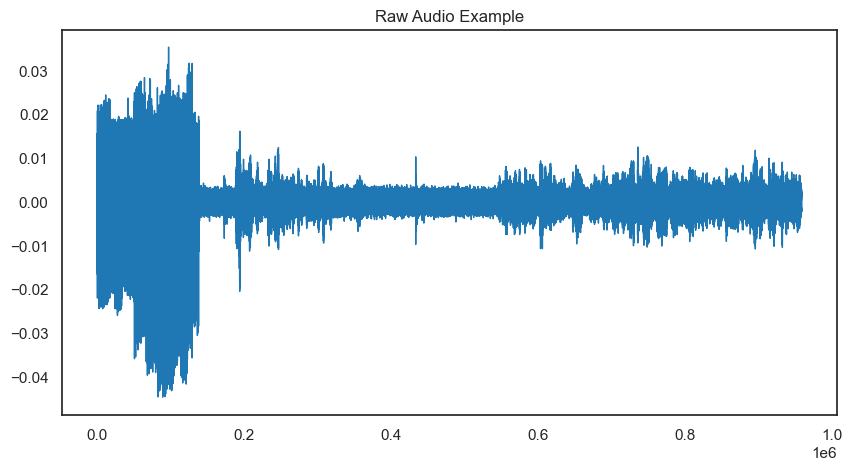

In [5]:
pd.Series(y).plot(
    figsize=(10, 5), 
    lw=1, 
    title="Raw Audio Example",
    color=color_pal[0])
plt.show()

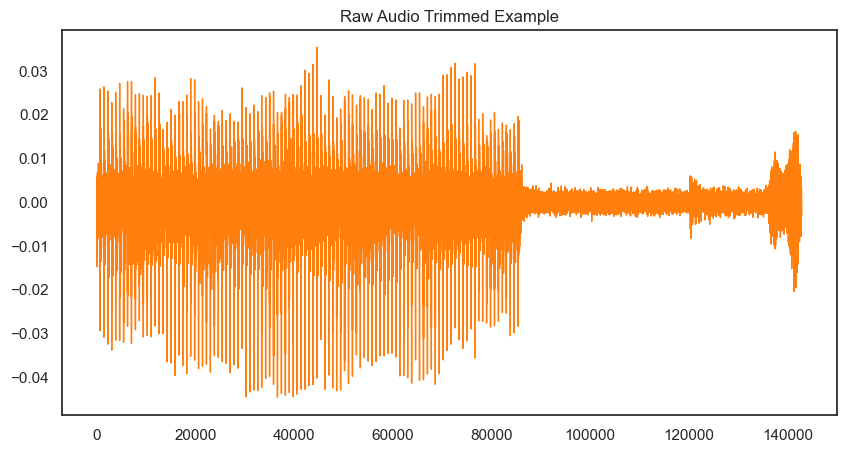

In [6]:
y_trimmed, _ = librosa.effects.trim(y, top_db=2)
pd.Series(y_trimmed).plot(
    figsize=(10, 5),
    lw=1,
    title="Raw Audio Trimmed Example",
    color=color_pal[1])
plt.show()


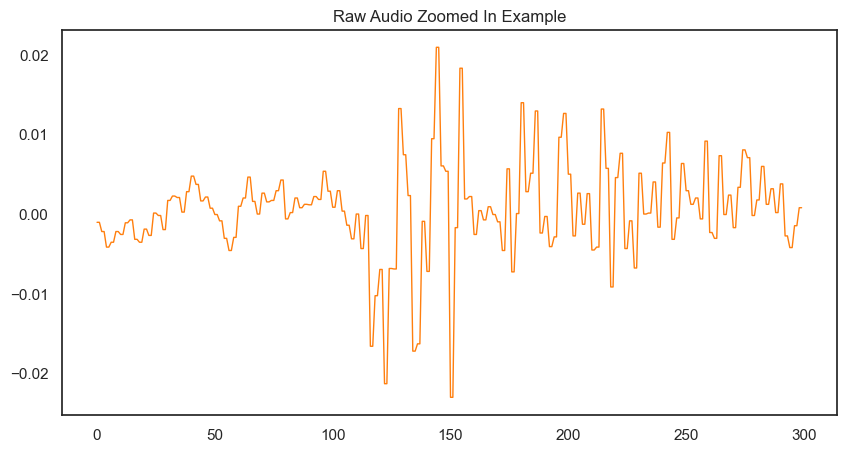

In [7]:
pd.Series(y[10000:10300]).plot(
    figsize=(10, 5),
    lw=1,
    title="Raw Audio Zoomed In Example",
    color=color_pal[1])
plt.show()


In [8]:
D = librosa.stft(y)
Sound_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
Sound_db.shape

(1025, 1873)

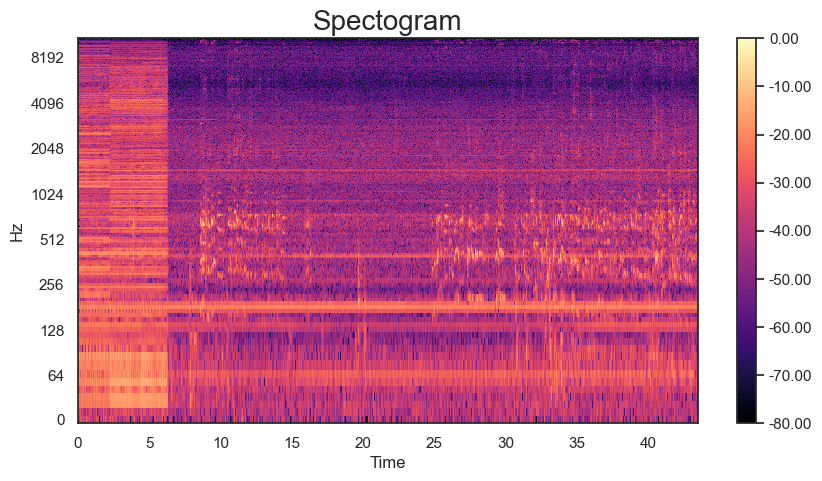

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(Sound_db,
                               x_axis="time",
                               y_axis="log",
                               ax=ax)

ax.set_title("Spectogram", fontsize=20)
fig.colorbar(img, ax=ax, format=f"%0.2f")
plt.show()

In [10]:
S = librosa.feature.melspectrogram(y=y,
                                   sr=sr,
                                   n_mels=128,)
Sound_db_mel = librosa.amplitude_to_db(S, ref=np.max)

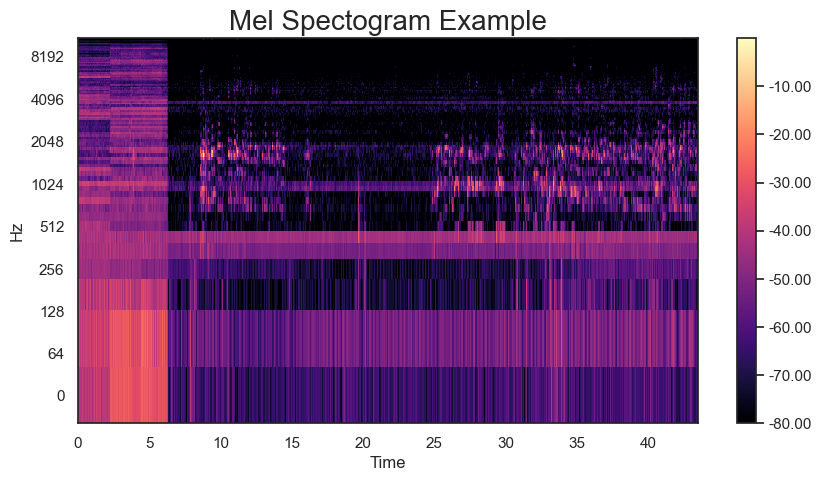

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
# Plot the mel spectogram
img = librosa.display.specshow(Sound_db_mel,
                               x_axis='time',
                               y_axis='log',
                               ax=ax)
ax.set_title('Mel Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()
